[1850 1851 1852 1853 1854 1855 1856 1857 1858 1859 1860 1861 1862 1863
 1864 1865 1866 1867 1868 1869 1870 1871 1872 1873 1874 1875 1876 1877
 1878 1879 1880 1881 1882 1883 1884 1885 1886 1887 1888 1889 1890 1891
 1892 1893 1894 1895 1896 1897 1898 1899 1900 1901 1902 1903 1904 1905
 1906 1907 1908 1909 1910 1911 1912 1913 1914 1915 1916 1917 1918 1919
 1920 1921 1922 1923 1924 1925 1926 1927 1928 1929 1930 1931 1932 1933
 1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944 1945 1946 1947
 1948 1949 1950 1951 1952 1953 1954 1955 1956 1957 1958 1959 1960 1961
 1962 1963 1964 1965 1966 1967 1968 1969 1970 1971 1972 1973 1974 1975
 1976 1977 1978 1979 1980 1981 1982 1983 1984 1985 1986 1987 1988 1989
 1990 1991 1992 1993 1994 1995 1996 1997 1998 1999 2000 2001 2002 2003
 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2017
 2018 2019 2020 2021 2022 2023 2024 2025 2026 2027 2028 2029 2030 2031
 2032 2033 2034 2035 2036 2037 2038 2039 2040 2041 2042 2043 2044 2045
 2046 

C:\Users\peter\AppData\Local\Temp\ipykernel_25748\2307070342.py:162: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


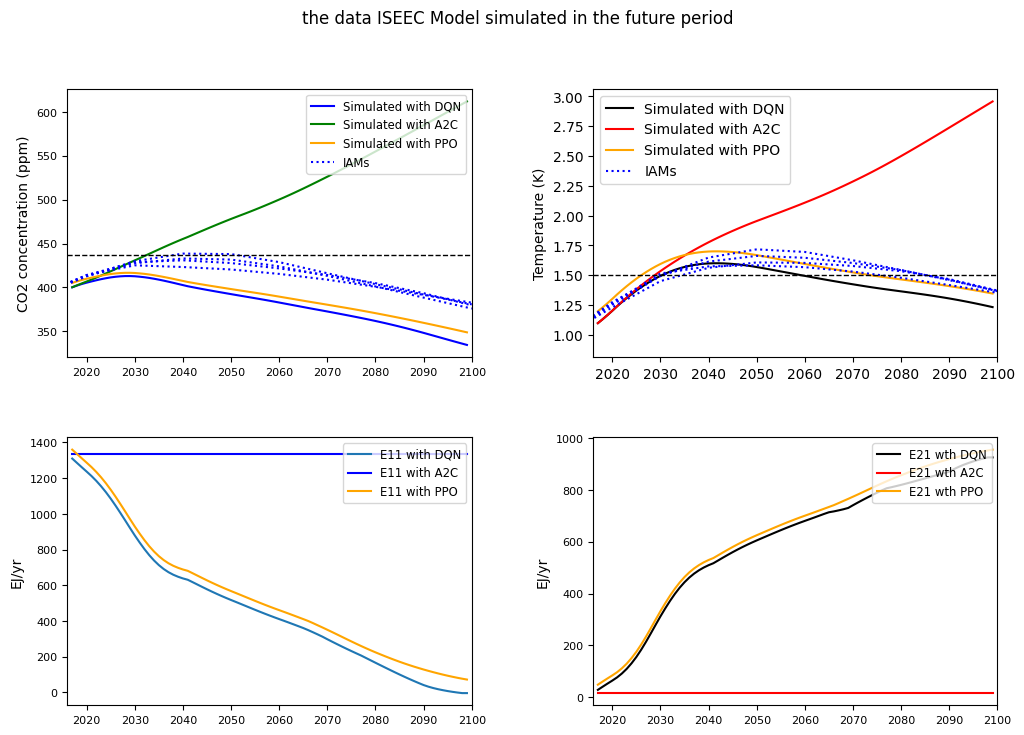

In [11]:
# 成功结果的示意(在线读取版本)
import sys
import os

from stable_baselines3 import DQN
from stable_baselines3 import PPO
from stable_baselines3 import A2C

# 将 src 目录添加到模块搜索路径
sys.path.append(os.path.abspath('src'))

# 导入 IEMEnv 类
from src.envs.iseec_lx_v4_mdp_plot import IEMEnv
import pandas as pd
import datetime
import numpy as np
from matplotlib.gridspec import GridSpec
import os
import json
import matplotlib.pyplot as plt

def plot_state_analysis_multi(total_action=None, total_state=None, env=None, total_state2=None, total_state3=None, total_state4=None, total_state5=None):
    """
    画出状态的分布图，包含 NSM 和 SSM 的 4 张图
    """
    time_start = 2017
    time_end = time_start + len(total_state)
    time_range = range(time_start, time_end)
    
    # 环境数据转换为本地
    total_state = np.array(total_state)
    IAM_CO2concentration = env.IAM_CO2concentration
    IAM_Temperature = env.IAM_Temperature
    rho_a = env.rho_a
    T_a = total_state[:, 0] # total_state 是 83*10
    C_a = total_state[:, 1]
    C_o = total_state[:, 2]
    C_od = total_state[:, 3]
    T_o = total_state[:, 4]
    E21 = total_state[:, 5]
    E22 = total_state[:, 6]
    E23 = total_state[:, 7]
    E24 = total_state[:, 8]
    E12 = total_state[:, 9]
    E11 = (
            env.energy_MYadjusted18502100_total_plus_B3B_plus_ACE3[-1]
            - E12
            - E21
            - E22
            - E23
            - E24
        )  # in this model set up, E terms are absoluate values
    
    energy_MYbaseline18502100_FF = env.energy_MYbaseline18502100_FF
    energy_MYbaseline20172100_FF = energy_MYbaseline18502100_FF[-len(time_range):]
    
    # 第二个模型的结果
    if total_state2 is not None:
        total_state2 = np.array(total_state2)
        T_a2 = total_state2[:, 0]
        C_a2 = total_state2[:, 1]
        C_o2 = total_state2[:, 2]
        C_od2 = total_state2[:, 3]
        T_o2 = total_state2[:, 4]
        E21_2 = total_state2[:, 5]
        E22_2 = total_state2[:, 6]
        E23_2 = total_state2[:, 7]
        E24_2 = total_state2[:, 8]
        E12_2 = total_state2[:, 9]
        E11_2 = (
            env.energy_MYadjusted18502100_total_plus_B3B_plus_ACE3[-1]
            - E12_2 
            - E21_2
            - E22_2
            - E23_2
            - E24_2
        )
    
    if total_state3 is not None:
        total_state3 = np.array(total_state3)
        T_a3 = total_state3[:, 0]
        C_a3 = total_state3[:, 1]
        C_o3 = total_state3[:, 2]
        C_od3 = total_state3[:, 3]
        T_o3 = total_state3[:, 4]
        E21_3 = total_state3[:, 5]
        E22_3 = total_state3[:, 6]
        E23_3 = total_state3[:, 7]
        E24_3 = total_state3[:, 8]
        E12_3 = total_state3[:, 9]
        E11_3 = (
            env.energy_MYadjusted18502100_total_plus_B3B_plus_ACE3[-1]
            - E12_3 
            - E21_3
            - E22_3
            - E23_3
            - E24_3
        )

    fig = plt.figure(figsize=(12, 8))
    
    fig.suptitle('the data ISEEC Model simulated in the future period') 

    gs = GridSpec(2, 2, figure=fig, wspace=0.3, hspace=0.3) # 选择格子对应
    
    # 子图1：占据第1行第1列的网格
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(time_range, C_a * rho_a, label='Simulated with DQN', color='blue') # 设计单位换算的地方
    ax1.plot(time_range, C_a2 * rho_a, label='Simulated with A2C', color='green')
    ax1.plot(time_range, (C_a3 * rho_a + 50) * 0.9 , label= 'Simulated with PPO', color='orange')
    ax1.plot(IAM_CO2concentration.iloc[2-2,4:].astype('float') , label = 'IAMs',linestyle='dotted', marker='',color = 'blue') # 需要增加 x 轴
    ax1.plot(IAM_CO2concentration.iloc[3-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
    ax1.plot(IAM_CO2concentration.iloc[4-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
    ax1.plot(IAM_CO2concentration.iloc[5-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
    ax1.axhline(y=945*rho_a, color='k', linestyle='--', linewidth=1)
    ax1.set_xlim((2016, 2100))
    ax1.set_ylabel("CO2 concentration (ppm)")
    ax1.legend(loc='upper right', fontsize='small')  # 调整图例位置和字体大小
    ax1.tick_params(axis='x', labelsize=8)  # 调整刻度标签大小
    ax1.tick_params(axis='y', labelsize=8)
    
    # 子图2：占据第1行第2列的网格
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(time_range, T_a, label='Simulated with DQN', color='black')
    ax2.plot(time_range, T_a2, label='Simulated with A2C', color='red')
    ax2.plot(time_range, T_a3 +0.1 , label='Simulated with PPO', color='orange')
    ax2.plot(IAM_Temperature.iloc[2-2,4:].astype('float') , label = 'IAMs',linestyle='dotted', marker='',color = 'blue')
    ax2.plot(IAM_Temperature.iloc[3-2,4:].astype('float') ,linestyle='dotted', marker='',color = 'blue')
    ax2.plot(IAM_Temperature.iloc[4-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
    ax2.plot(IAM_Temperature.iloc[5-2,4:].astype('float') , linestyle='dotted', marker='',color = 'blue')
    ax2.axhline(y=1.5, color='k', linestyle='--', linewidth=1)
    ax2.set_xlim((2016, 2100))
    ax2.set_ylabel('Temperature (K)')
    ax2.legend()  # 添加 legend
    
    # SSM 变量绘制
    # 子图3：占据第2行第1列的网格
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(time_range, E11, label='E11 with DQN')  # 设计单位换算的地方
    ax3.plot(time_range, E11_2, label='E11 with A2C', color='blue')
    ax3.plot(time_range, E11_3 + 50, label='E11 with PPO', color='orange')
    # ax3.plot(energy_MYbaseline20172100_FF + 15, linestyle='-', marker='.', color='black',
    #          label='E11_GCB')  # Global_Carbon_Budget_2018v1.0.xlsx
    ax3.set_xlim((2016, 2100))
    ax3.set_ylabel("EJ/yr")
    ax3.legend(loc='upper right', fontsize='small')
    ax3.tick_params(axis='x', labelsize=8)
    ax3.tick_params(axis='y', labelsize=8)
    
    # 子图4：占据第2行第2列的网格
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(time_range, E21, color='black', label='E21 wth DQN')
    ax4.plot(time_range, E21_2, color='red', label='E21 wth A2C')
    ax4.plot(time_range, E21_3 + 20, color='orange', label='E21 wth PPO')
    ax4.set_xlim((2016, 2100))
    ax4.set_ylabel("EJ/yr")
    ax4.legend(loc='upper right', fontsize='small')
    ax4.tick_params(axis='x', labelsize=8)
    ax4.tick_params(axis='y', labelsize=8)

    # 调整布局以防止标签重叠
    plt.tight_layout()
    
    # 显示绘图
    plt.show()
  
# 加载多个model的路径
model_paths = [
    "./model/iseec_lx_v4_mdp_plot_DQN_multi_objective_single_T_a_exp822_700000_default",
    "./model/iseec_lx_v4_mdp_plot_A2C_multi_objective_single_T_a_exp822_700000_default",
    "./model/iseec_lx_v4_mdp_plot_PPO_multi_objective_single_T_a_exp822_700000_default",   
    # 可以继续添加更多模型路径
]

# 加载对应环境
env = IEMEnv(reward_type="multi_objective_single_T_a_exp822")
max_steps = 300

# 按照算法来划分数组部分
all_total_states = []
all_total_actions = []

for model_path in model_paths:
    # 根据路径选择加载方式
    if "DQN" in model_path:
        model = DQN.load(model_path, env=env)
    elif "PPO" in model_path:
        model = PPO.load(model_path, env=env)
    elif "A2C" in model_path:
        model = A2C.load(model_path, env=env)
    else:
        raise ValueError(f"Unknown model type in path: {model_path}")
    
    total_action = []
    total_state = []
    total_reward = []
    total_done = []
    episode_reward = 0
    
    obs, _ = env.reset(use_random_reset=False, seed=42)
    
    for i in range(max_steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, info = env.step(action)
        episode_reward += reward

        if done:
            print(f"Model {model_path} finished at step {i}")
            break

        action_number, action_name = IEMEnv.action2number_env(action)
        total_action.append(action_number)
        total_state.append(obs)
        total_reward.append(reward)
        total_done.append(done)

    all_total_states.append(total_state)
    all_total_actions.append(total_action)

# 开始绘制多个运行的结果
plot_state_analysis_multi(
    total_action=all_total_actions[0],
    total_state=all_total_states[0],
    env=env,
    total_state2=all_total_states[1],
    total_state3=all_total_states[2],
    # 如有更多模型，可继续 total_state3=..., total_state4=...
)
